In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Import du jeu de donnée asssemblé mais non nettoyé
df = pd.read_csv("/Users/alizeeblanchon/Documents/Data_Scientist/data_project/mai25_bds_accidents/data/raw/accidents_2019_2023.csv")


/var/folders/zf/7kchqtxx0kb4wh2ykpks70k40000gn/T/ipykernel_11270/2267022127.py:2: DtypeWarning: Columns (42,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/alizeeblanchon/Documents/Data_Scientist/data_project/mai25_bds_accidents/data/raw/accidents_2019_2023.csv")


In [4]:
# Appercu global du dataframe
lig = df.shape[0]
col = df.shape[1]
print("Le dataset contient ",lig, "lignes et ",col," colonnes")
print("----"*10)
print("noms des colonnes : ")
print(df.columns)
print("----"*10)
print(df.dtypes)
print("----"*10)
df.head()


Le dataset contient  657865 lignes et  54  colonnes
----------------------------------------
noms des colonnes : 
Index(['Num_Acc', 'id_vehicule', 'num_veh', 'senc', 'catv', 'obs', 'obsm',
       'choc', 'manv', 'motor', 'occutc', 'place', 'catu', 'grav', 'sexe',
       'an_nais', 'trajet', 'secu1', 'secu2', 'secu3', 'locp', 'actp', 'etatp',
       'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg', 'int', 'atm',
       'col', 'adr', 'lat', 'long', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv',
       'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf',
       'infra', 'situ', 'vma'],
      dtype='object')
----------------------------------------
Num_Acc          int64
id_vehicule     object
num_veh         object
senc             int64
catv             int64
obs              int64
obsm             int64
choc             int64
manv             int64
motor            int64
occutc         float64
place            int64
catu             int64
grav             int64
sexe    

,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,...,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,201900000001,138 306 524,B01,2,7,0,2,5,23,1,...,1,6,900,2,NaN,NaN,1,2,1,70
1,201900000001,138 306 524,B01,2,7,0,2,5,23,1,...,1,6,900,2,NaN,NaN,1,2,1,70
2,201900000001,138 306 525,A01,2,17,1,0,3,11,1,...,1,6,900,2,NaN,NaN,1,2,1,70
3,201900000002,138 306 523,A01,1,7,4,0,1,0,1,...,4,3,845,2,NaN,NaN,1,0,1,70
4,201900000003,138 306 520,A01,1,7,0,2,1,2,1,...,1,10,500,3,NaN,NaN,1,0,1,90


In [16]:
# Statistiques descriptives du dataset
df.describe()


,Num_Acc,senc,catv,obs,obsm,choc,manv,motor,occutc,place,...,catr,v1,circ,vosp,prof,plan,surf,infra,situ,vma
count,6.578650e+05,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000,8938.000000,657865.000000,...,657865.000000,633269.000000,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000
mean,2.021126e+11,1.568614,12.720155,1.102202,1.583977,2.873802,7.067578,1.229524,6.776236,2.093238,...,3.303587,-0.155135,1.810692,0.184752,1.226843,1.278802,1.253792,0.812632,1.477238,59.254358
std,1.463055e+08,0.827607,13.488152,3.230166,1.192413,2.396278,8.014907,1.050140,11.086558,2.591587,...,1.256788,0.382831,0.912122,0.670684,0.545919,0.660801,0.784540,2.164946,1.429355,26.026253
min,2.019000e+11,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,...,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2.020000e+11,1.000000,7.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,3.000000,0.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,50.000000
50%,2.021000e+11,1.000000,7.000000,0.000000,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000,...,3.000000,0.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,50.000000
75%,2.022001e+11,2.000000,10.000000,0.000000,2.000000,4.000000,15.000000,1.000000,6.000000,2.000000,...,4.000000,0.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,80.000000
max,2.023001e+11,3.000000,99.000000,17.000000,9.000000,9.000000,26.000000,6.000000,65.000000,10.000000,...,9.000000,3.000000,4.000000,3.000000,4.000000,4.000000,9.000000,9.000000,8.000000,901.000000


In [6]:
# Constat des Na
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

lartpc     99.823672
occutc     98.641363
v2         91.918555
larrout    20.087100
voie       11.546442
v1          3.738761
adr         1.535573
an_nais     1.436921
dtype: float64


In [5]:
df.nunique()

Num_Acc        273226
id_vehicule    463184
num_veh            81
senc                5
catv               32
obs                19
obsm                8
choc               11
manv               28
motor               8
occutc             40
place              11
catu                3
grav                5
sexe                3
an_nais           112
trajet              8
secu1              11
secu2              11
secu3              11
locp               11
actp               13
etatp               4
jour               31
mois               12
an                  5
hrmn             1440
lum                 6
dep               116
com             22984
agg                 2
int                10
atm                10
col                 8
adr            104498
lat            257154
long           259671
catr                8
voie            44907
v1                  4
v2                 44
circ                5
nbv                31
vosp                5
prof                5
pr        

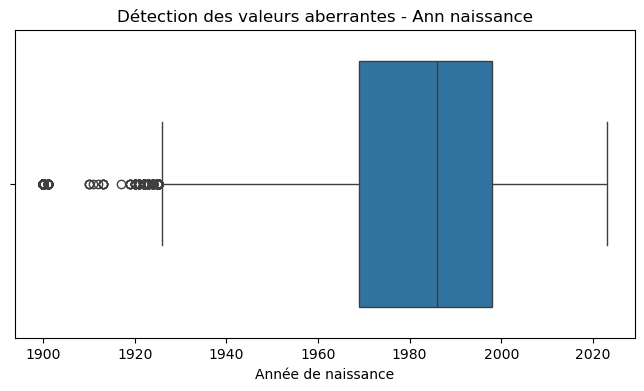

1900.0


In [ ]:
# Detection des valeurs aberrantes par boxplot


plt.figure(figsize=(8, 4))
sns.boxplot(x=df["an_nais"])
plt.title("Détection des valeurs aberrantes - Ann naissance")
plt.xlabel("Année de naissance")
plt.show()

min = df["an_nais"].min()
print(min)

In [ ]:
# Detection des valeur aberrantes par intervalle inter quartile
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["age"] < Q1 - 1.5 * IQR) | (df["age"] > Q3 + 1.5 * IQR)]
print(f"Nombre de valeurs aberrantes sur l'âge : {len(outliers)}")

grav
 1    42.290744
 4    39.889795
 3    15.176822
 2     2.573172
-1     0.069467
Name: proportion, dtype: float64
grav
 1    42.29
 4    39.89
 3    15.18
 2     2.57
-1     0.07
Name: proportion, dtype: float64


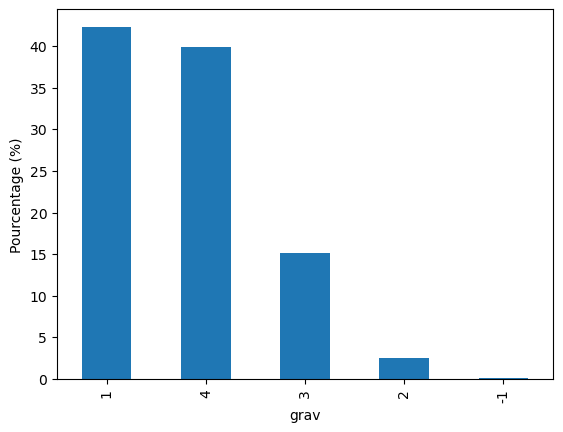

In [30]:
# Afficher la distribution en proportions (pourcentage)
percentages = df['grav'].value_counts(normalize=True) * 100
print(percentages)

# Ou avec un affichage arrondi à 2 décimales
print(percentages.round(2))

# Optionnel : afficher en barplot avec pourcentage en y
import matplotlib.pyplot as plt
percentages.plot(kind='bar')
plt.ylabel('Pourcentage (%)')
plt.show()

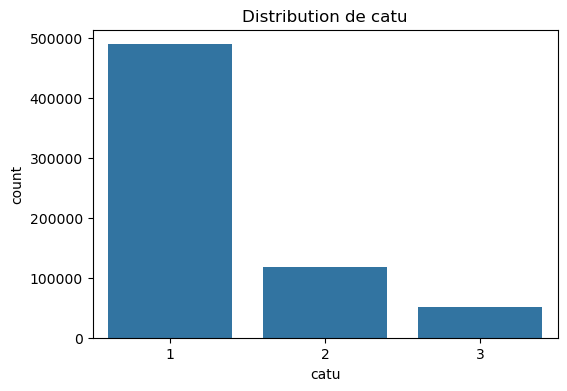

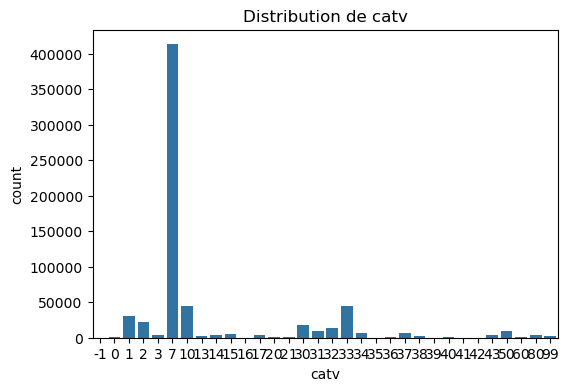

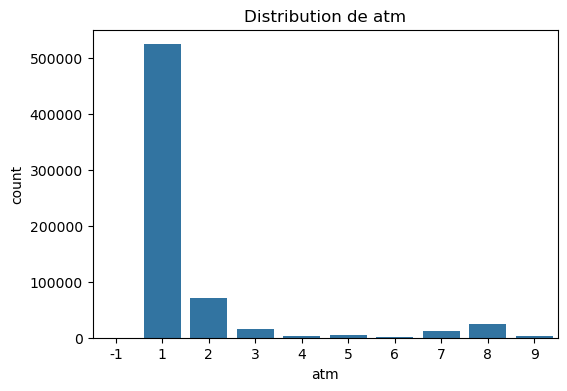

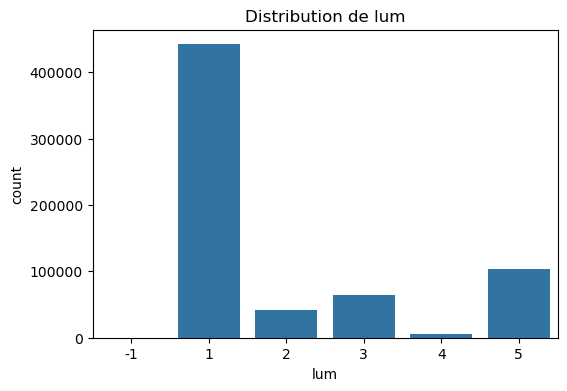

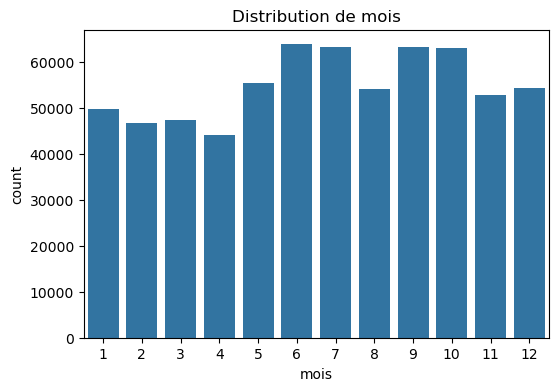

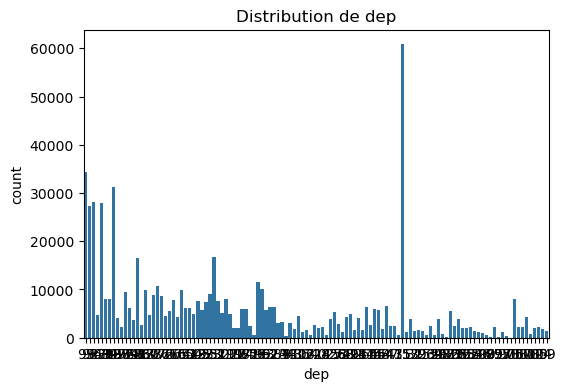

In [33]:
# Analyse par colonne
for col in ['catu', 'catv', 'atm', 'lum','mois','dep']:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution de {col}")
    plt.show()

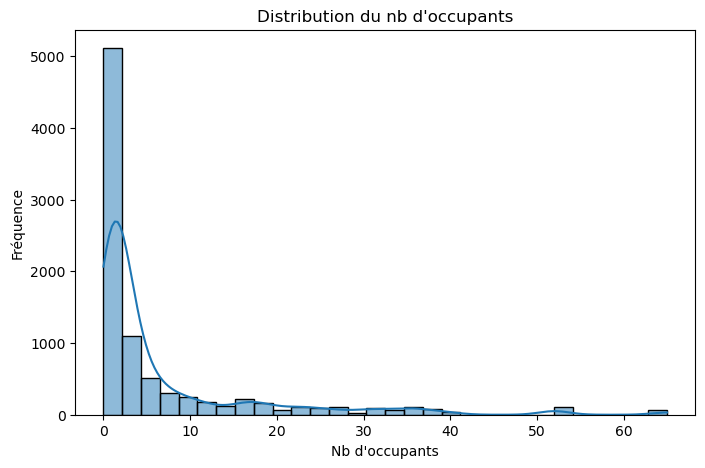

In [24]:
# Analyse univariée 
# Variable numérique
df["occutc"].describe()

plt.figure(figsize=(8,5))
sns.histplot(df["occutc"], bins=30, kde=True)
plt.title("Distribution du nb d'occupants")
plt.xlabel("Nb d'occupants")
plt.ylabel("Fréquence")
plt.show()

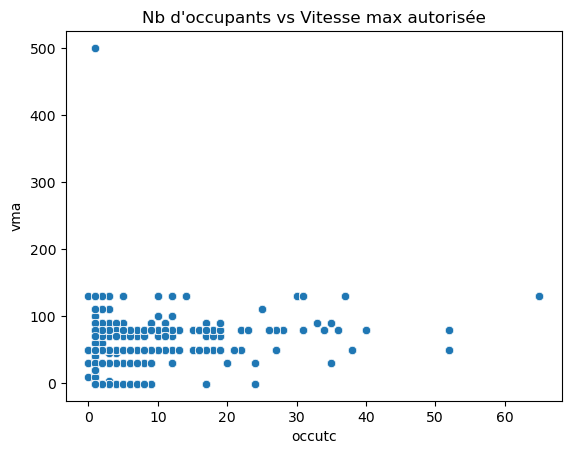

In [26]:
# Analyse bivariée
# numérique vs numérique
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="occutc", y="vma")
plt.title("Nb d'occupants vs Vitesse max autorisée")
plt.show()

In [27]:
# Analyse bivariée
# catégorielle vs catégorielle
pd.crosstab(df["sexe"], df["grav"], normalize="index")

grav,-1,1,2,3,4
sexe,,,,,
-1,0.049983,0.950017,0.000000,0.000000,0.000000
1,0.000007,0.435398,0.029886,0.159990,0.374719
2,0.000000,0.372747,0.017923,0.140766,0.468564


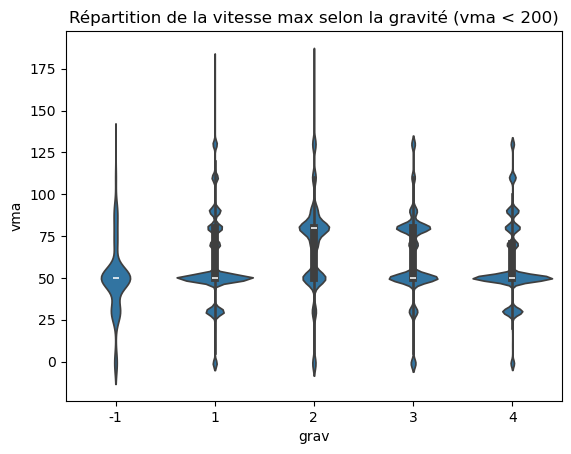

In [3]:
# Analyse bivariée
# Catégorielle vs numérique
# ou : sns.violinplot(data=df, x="grav", y="vma")
df_filtered = df[df['vma'] < 200]

sns.violinplot(data=df_filtered, x="grav", y="vma")
plt.title("Répartition de la vitesse max selon la gravité (vma < 200)")
plt.show()

In [4]:
from scipy.stats import kruskal

groupes = [df[df["grav"] == g]["vma"].dropna() for g in df["grav"].unique()]
stat, p = kruskal(*groupes)
print(f"Kruskal-Wallis test : stat={stat:.3f}, p-value={p:.5f}")

Kruskal-Wallis test : stat=9645.418, p-value=0.00000


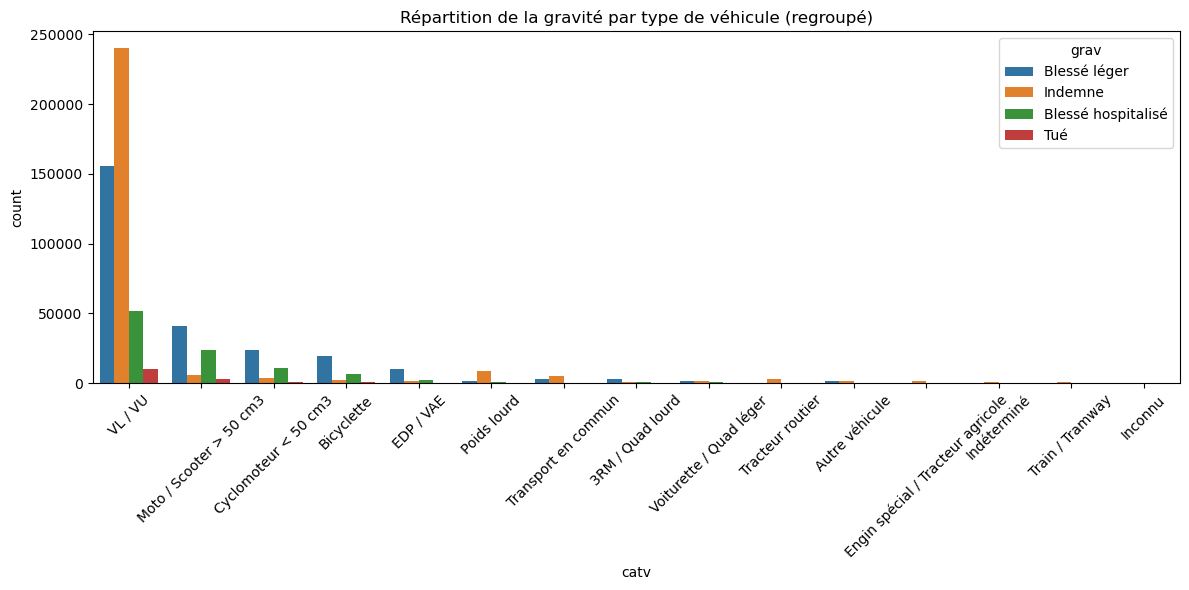

grav                               Blessé hospitalisé  Blessé léger   Indemne  \
catv                                                                            
3RM / Quad lourd                             0.250518      0.556361  0.156237   
Autre véhicule                               0.141560      0.422999  0.427707   
Bicyclette                                   0.230079      0.657920  0.077590   
Cyclomoteur < 50 cm3                         0.268107      0.610793  0.102386   
EDP / VAE                                    0.159525      0.710591  0.109542   
Engin spécial / Tracteur agricole            0.114260      0.166819  0.674132   
Inconnu                                      0.277778      0.055556  0.444444   
Indéterminé                                  0.152720      0.330544  0.485356   
Moto / Scooter > 50 cm3                      0.321748      0.549851  0.083641   
Poids lourd                                  0.065694      0.140580  0.762945   
Tracteur routier            

In [43]:
# Analyse bivariée catv
# Fonction de regroupement des catégories de véhicules
def regrouper_catv(catv):
    if catv in [1]:
        return "Bicyclette"
    elif catv in [2, 30]:
        return "Cyclomoteur < 50 cm3"
    elif catv in [3, 35]:
        return "Voiturette / Quad léger"
    elif catv in [31, 32, 33, 34]:
        return "Moto / Scooter > 50 cm3"
    elif catv in [36, 41, 42, 43]:
        return "3RM / Quad lourd"
    elif catv in [4, 5, 6, 8, 9, 11, 12, 18, 19]:
        return "Réf. inutilisée"
    elif catv in [7, 10]:
        return "VL / VU"
    elif catv in [13, 14, 15]:
        return "Poids lourd"
    elif catv in [16, 17]:
        return "Tracteur routier"
    elif catv in [20, 21]:
        return "Engin spécial / Tracteur agricole"
    elif catv in [37, 38]:
        return "Transport en commun"
    elif catv in [39, 40]:
        return "Train / Tramway"
    elif catv in [50, 60, 80]:
        return "EDP / VAE"
    elif catv == 99:
        return "Autre véhicule"
    elif catv == 0:
        return "Indéterminé"
    else:
        return "Inconnu"

# Création d'une série temporaire regroupée
catv_regroupe = df["catv"].apply(regrouper_catv)
# Dictionnaire de mapping
grav_map = {
    1: "Indemne",
    2: "Tué",
    3: "Blessé hospitalisé",
    4: "Blessé léger"
}

# Creation de serie temporaires
catv_regroupe = df["catv"].apply(regrouper_catv)
grav_label = df["grav"].map(grav_map)

plt.figure(figsize=(12, 6))
sns.countplot(x=catv_regroupe, hue=grav_label,
              order=catv_regroupe.value_counts().index)
plt.xticks(rotation=45)
plt.title("Répartition de la gravité par type de véhicule (regroupé)")
plt.tight_layout()
plt.show()

ct_norm = pd.crosstab(catv_regroupe, grav_label, normalize='index')
print(ct_norm)



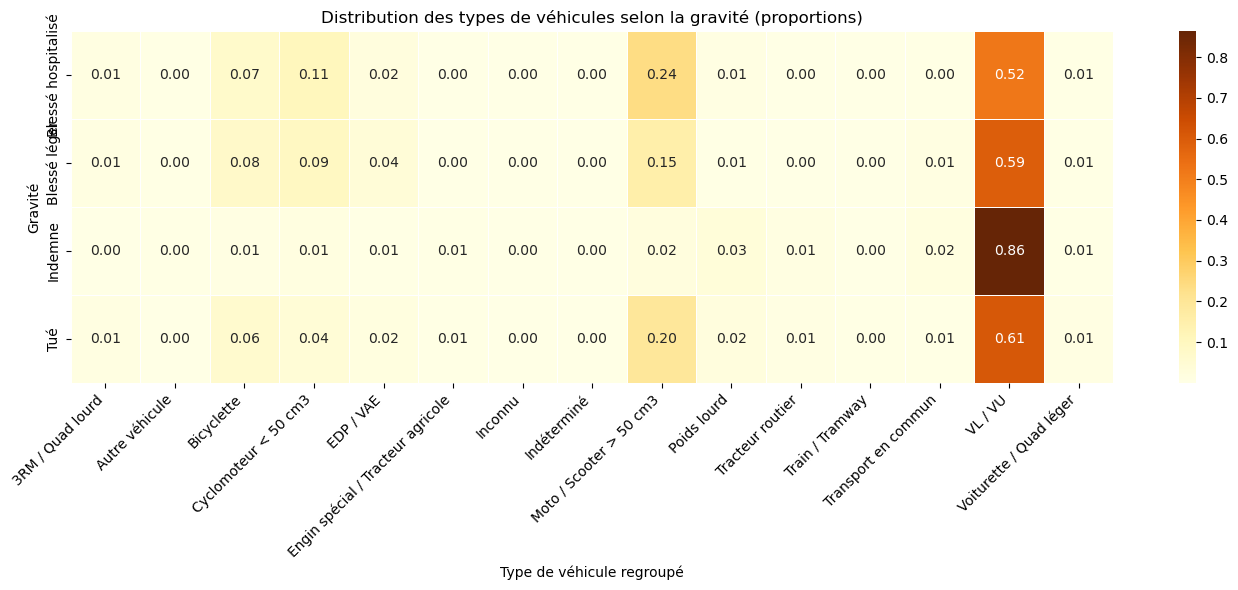

In [50]:
crosstab_percent = pd.crosstab(
    df["grav"].map({
        1: "Indemne",
        2: "Tué",
        3: "Blessé hospitalisé",
        4: "Blessé léger"
    }),
    df["catv"].apply(regrouper_catv),
    normalize="index"
)
# heatmap

plt.figure(figsize=(14, 6))
sns.heatmap(crosstab_percent, annot=True, fmt=".2f", cmap="YlOrBr", linewidths=0.5)
plt.title("Distribution des types de véhicules selon la gravité (proportions)")
plt.xlabel("Type de véhicule regroupé")
plt.ylabel("Gravité")
plt.xticks(rotation=45, ha='right')     # Pour l’axe X (types de véhicule)
plt.yticks(rotation=90)                 # Pour l’axe Y (gravité)
plt.tight_layout()
plt.show()

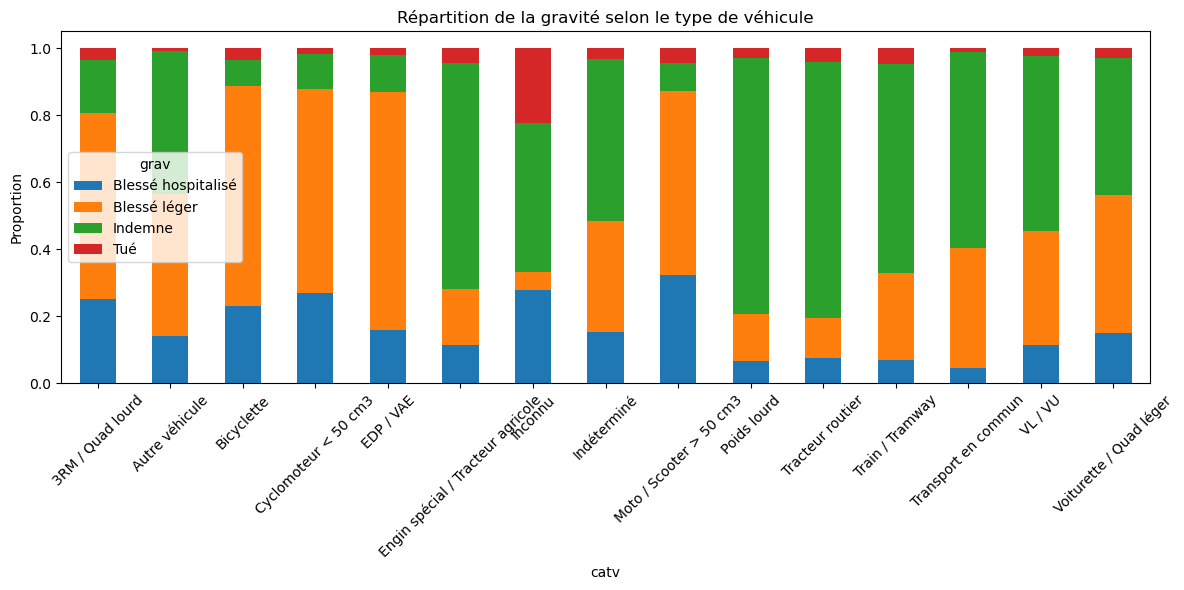

In [53]:
catv_regroupe = df["catv"].apply(regrouper_catv)  # fonction déjà définie
grav_map = {
    1: "Indemne",
    2: "Tué",
    3: "Blessé hospitalisé",
    4: "Blessé léger"
}
grav_label = df["grav"].map(grav_map)

pd.crosstab(catv_regroupe, grav_label, normalize="index").plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Répartition de la gravité selon le type de véhicule")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
import scipy.stats as stats
# test stat du graph précedent
# Table de contingence
contingency_table = pd.crosstab(catv_regroupe, grav_label)

# Test du chi-carré d'indépendance
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi2 statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("=> Il existe une association significative entre la gravité et le type de véhicule.")
else:
    print("=> Pas d'association significative détectée entre la gravité et le type de véhicule.")


Chi2 statistic: 110086.93
Degrees of freedom: 42
P-value: 0.0000
=> Il existe une association significative entre la gravité et le type de véhicule.


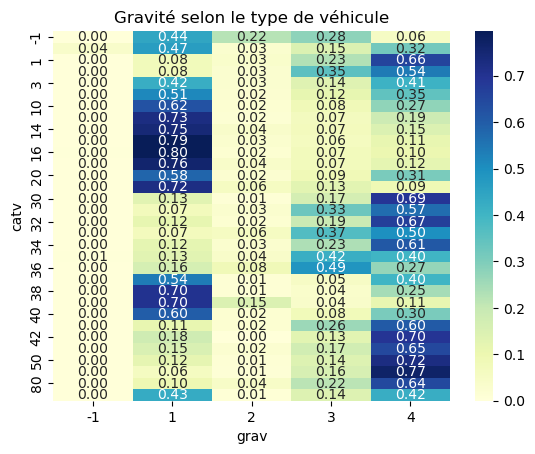

In [31]:
# Heatmap var catégorielle

table = pd.crosstab(df["catv"], df["grav"], normalize="index")
sns.heatmap(table, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Gravité selon le type de véhicule")
plt.show()


/var/folders/zf/7kchqtxx0kb4wh2ykpks70k40000gn/T/ipykernel_4635/1920218803.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, palette='viridis')


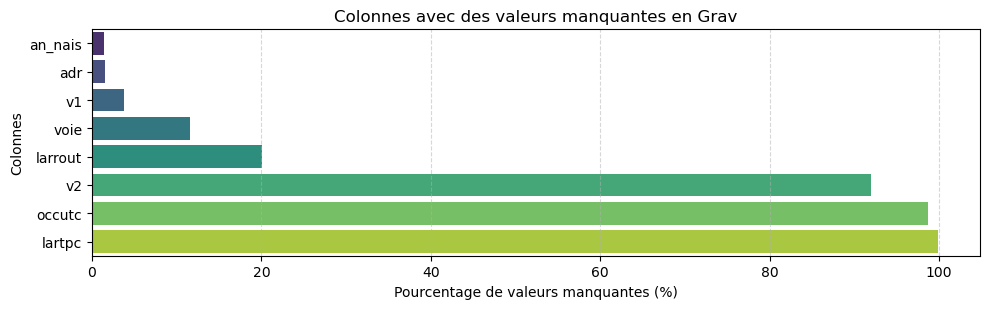

In [ ]:

# Calcul du pourcentage de NaN
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=True)

# Filtrer pour n'afficher que les colonnes avec > 1% de NaN (ajustable)
missing = missing[missing > 1]

# Plot amélioré
plt.figure(figsize=(10, len(missing) * 0.4))
sns.barplot(x=missing.values, y=missing.index, palette='viridis')
plt.xlabel("Pourcentage de valeurs manquantes (%)")
plt.ylabel("Colonnes")
plt.title("Colonnes avec des valeurs manquantes en Grav")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

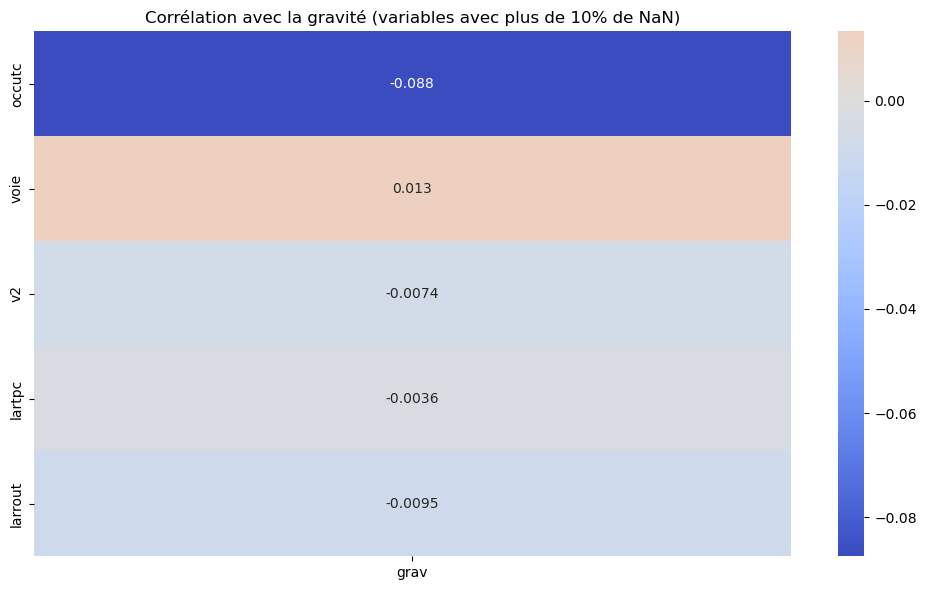

In [19]:

# 1. Identifier les colonnes avec beaucoup de NaN (ex: +50%)
na_ratio = df.isnull().mean()
cols_many_na = na_ratio[na_ratio > 0.1].index.tolist()

# 2. Ajouter la variable cible
cols_corr = cols_many_na + ['grav']

# 3. Sous-ensemble du dataframe
df_subset = df[cols_corr].copy()

# 4. Encodage temporaire des colonnes catégorielles (sans nettoyage complet)
for col in df_subset.columns:
    if df_subset[col].dtype == 'object':
        df_subset[col] = df_subset[col].astype('category').cat.codes

# 5. Calcul de la corrélation (pandas gère les NaN automatiquement avec pairwise deletion)
corr_matrix = df_subset.corr()

# 6. Affichage de la heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix[['grav']].drop('grav'), annot=True, cmap='coolwarm', center=0)
plt.title("Corrélation avec la gravité (variables avec plus de 10% de NaN)")
plt.tight_layout()
plt.show()

In [7]:
df["an_nais"].value_counts().sort_index()

an_nais
1900.0     148
1901.0      43
1910.0       3
1911.0       1
1912.0       1
          ... 
2019.0    1646
2020.0    1186
2021.0     898
2022.0     596
2023.0     212
Name: count, Length: 112, dtype: int64

(657865, 54)


40